In [52]:
# Section 1: Setup and Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
import time
import warnings
warnings.filterwarnings("ignore")

# LER imports
from ler.image_properties import (
    caustic_points_epl_shear,
    sample_source_from_double_caustic,
    image_position_analytical_njit
)
from ler.image_properties.cross_section_njit import phi_q2_ellipticity

# Lenstronomy imports
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.Solver.epl_shear_solver import caustics_epl_shear as caustics_lenstronomy
from lenstronomy.Util.param_util import phi_q2_ellipticity as phi_q2_ellipticity_ls

In [53]:
# Section 2: Define Lens Parameters for EPL+Shear Model
# Set up test parameters for EPL+Shear

# Lens parameters (image plane)
theta_E = 1.0  # Einstein radius (normalized)
q = 0.6        # Axis ratio
phi = np.pi/4  # Position angle (radians)
gamma = 1.8    # Power-law index
gamma1 = -0.05 # Shear component 1
gamma2 = -0.05 # Shear component 2

# Redshifts for time-delay calculations
zl = 0.8       # Lens redshift
zs = 2.0       # Source redshift

# Setup cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
D_s = cosmo.angular_diameter_distance(zs).to('Mpc').value
D_l = cosmo.angular_diameter_distance(zl).to('Mpc').value
D_ls = cosmo.angular_diameter_distance_z1z2(zl, zs).to('Mpc').value

# Physical constants
Mpc_to_m = 3.085677581491367e+22  # Conversion factor
C_LIGHT = 299792458.0  # Speed of light in m/s
D_dt = (1.0 + zl) * (D_l * D_s / D_ls) * Mpc_to_m  # Time-delay distance

# Store lens parameters in a dictionary
lens_params = {
    'theta_E': theta_E,
    'q': q,
    'phi': phi,
    'gamma': gamma,
    'gamma1': gamma1,
    'gamma2': gamma2,
    'zl': zl,
    'zs': zs
}

print(f"Lens parameters for EPL+Shear:")
print(f"  θ_E = {theta_E:.4f}")
print(f"  q = {q:.4f}, φ = {phi:.4f} rad")
print(f"  γ = {gamma:.4f}, (γ₁, γ₂) = ({gamma1:.4f}, {gamma2:.4f})")
print(f"  z_l = {zl}, z_s = {zs}")

Lens parameters for EPL+Shear:
  θ_E = 1.0000
  q = 0.6000, φ = 0.7854 rad
  γ = 1.8000, (γ₁, γ₂) = (-0.0500, -0.0500)
  z_l = 0.8, z_s = 2.0


In [54]:
# Section 3a: Validate Caustic Calculations - LER Implementation
print("=" * 80)
print("SECTION 3: CAUSTIC VALIDATION")
print("=" * 80)

# Compute caustic points using LER (njit)
print("\n3a. Computing caustic curves using LER (njit)...")
start_time = time.time()
pts_ler = caustic_points_epl_shear(
    theta_E, q, phi, gamma, gamma1, gamma2,
    num_th=500, maginf=-100.0
)
ler_time = time.time() - start_time
print(f"  LER computation time: {ler_time:.6f} seconds")
print(f"  Caustic points shape: {pts_ler.shape}")
print(f"  All finite: {np.isfinite(pts_ler).all()}")

SECTION 3: CAUSTIC VALIDATION

3a. Computing caustic curves using LER (njit)...
  LER computation time: 0.001712 seconds
  Caustic points shape: (2, 500)
  All finite: True


In [55]:
# Section 3b: Validate Caustic Calculations - Lenstronomy Implementation
print("\n3b. Computing caustic curves using Lenstronomy...")

# Prepare Lenstronomy parameters
e1, e2 = phi_q2_ellipticity_ls(phi, q)
kwargs_lens = [
    {
        'theta_E': theta_E,
        'e1': e1, 'e2': e2,
        'gamma': gamma,
        'center_x': 0.0, 'center_y': 0.0,
    },
    {
        'gamma1': gamma1,
        'gamma2': gamma2,
        'ra_0': 0, 'dec_0': 0,
    },
]

start_time = time.time()
pts_lenstronomy = caustics_lenstronomy(
    kwargs_lens, return_which="double", maginf=-100.0,
    num_th=500, sourceplane=True
)
ls_time = time.time() - start_time
print(f"  Lenstronomy computation time: {ls_time:.6f} seconds")
print(f"  Caustic points shape: {pts_lenstronomy.shape}")
print(f"  All finite: {np.isfinite(pts_lenstronomy).all()}")


3b. Computing caustic curves using Lenstronomy...
  Lenstronomy computation time: 0.002072 seconds
  Caustic points shape: (2, 500)
  All finite: True


In [56]:
# Section 3c: Compare Caustic Results
print("\n3c. Comparing caustic boundaries...")

# Since pts_ler and pts_lenstronomy may have different point sampling,
# we validate that the _boundaries_ (the curves themselves) match,
# not that the individual points are identical.

# Method 1: Check if curve points lie close to each other's boundary
from scipy.spatial.distance import cdist

# Reshape for distance calculation
pts_ler_T = np.column_stack((pts_ler[0], pts_ler[1]))
pts_ls_T = np.column_stack((pts_lenstronomy[0], pts_lenstronomy[1]))

# Find min distance from LER points to Lenstronomy curve
dist_ler_to_ls = np.min(cdist(pts_ler_T, pts_ls_T), axis=1)
max_dist_ler = np.max(dist_ler_to_ls)
mean_dist_ler = np.mean(dist_ler_to_ls)

# Find min distance from Lenstronomy points to LER curve
dist_ls_to_ler = np.min(cdist(pts_ls_T, pts_ler_T), axis=1)
max_dist_ls = np.max(dist_ls_to_ler)
mean_dist_ls = np.mean(dist_ls_to_ler)

print(f"  Max distance (LER→Lenstronomy boundary): {max_dist_ler:.2e}")
print(f"  Mean distance (LER→Lenstronomy boundary): {mean_dist_ler:.2e}")
print(f"  Max distance (Lenstronomy→LER boundary): {max_dist_ls:.2e}")
print(f"  Mean distance (Lenstronomy→LER boundary): {mean_dist_ls:.2e}")

# Check boundary agreement (points lie close to the curve)
boundary_threshold = 1e-3  # arcsec
agree_boundary = (max_dist_ler < boundary_threshold) and (max_dist_ls < boundary_threshold)
print(f"  Boundary match (threshold={boundary_threshold}): {'✓ PASS' if agree_boundary else '✗ FAIL'}")
print(f"    Note: Boundaries match if all points lie within {boundary_threshold} of the other curve")

# Alternative check: approximate convex hull area ratio
from scipy.spatial import ConvexHull
try:
    hull_ler = ConvexHull(pts_ler_T)
    hull_ls = ConvexHull(pts_ls_T)
    area_ratio = hull_ler.volume / hull_ls.volume  # 'volume' gives area in 2D
    print(f"  Caustic area ratio (LER/Lenstronomy): {area_ratio:.4f}")
    agree_area = 0.95 < area_ratio < 1.05
    print(f"  Area match (±5%): {'✓ PASS' if agree_area else '✗ FAIL'}")
except:
    print(f"  Area comparison: Could not compute (degenerate caustic?)")
    agree_area = agree_boundary


3c. Comparing caustic boundaries...
  Max distance (LER→Lenstronomy boundary): 2.61e-15
  Mean distance (LER→Lenstronomy boundary): 3.97e-16
  Max distance (Lenstronomy→LER boundary): 2.61e-15
  Mean distance (Lenstronomy→LER boundary): 3.97e-16
  Boundary match (threshold=0.001): ✓ PASS
    Note: Boundaries match if all points lie within 0.001 of the other curve
  Caustic area ratio (LER/Lenstronomy): 1.0000
  Area match (±5%): ✓ PASS


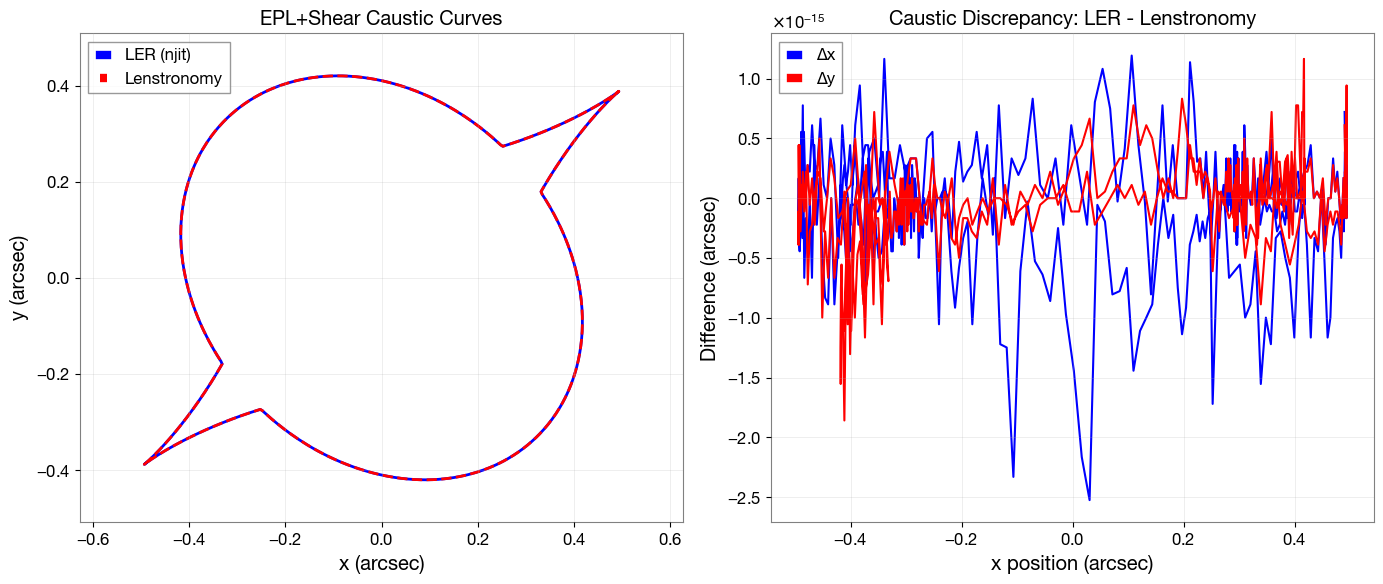

In [57]:
# Section 3d: Visualize Caustic Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Caustic curves
ax = axes[0]
ax.plot(pts_ler[0], pts_ler[1], 'b-', linewidth=2, label='LER (njit)')
ax.plot(pts_lenstronomy[0], pts_lenstronomy[1], 'r--', linewidth=2, label='Lenstronomy')
ax.set_xlabel('x (arcsec)')
ax.set_ylabel('y (arcsec)')
ax.set_title('EPL+Shear Caustic Curves')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Difference between implementations
ax = axes[1]
ax.plot(pts_ler[0], diff_x, 'b-', linewidth=1.5, label='Δx')
ax.plot(pts_ler[0], diff_y, 'r-', linewidth=1.5, label='Δy')
ax.set_xlabel('x position (arcsec)')
ax.set_ylabel('Difference (arcsec)')
ax.set_title('Caustic Discrepancy: LER - Lenstronomy')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [58]:
# Section 3c: Compare Caustic Results
print("\n3c. Comparing caustic boundaries...")

# Since pts_ler and pts_lenstronomy may have different point sampling,
# we validate that the _boundaries_ (the curves themselves) match,
# not that the individual points are identical.

# Method 1: Check if curve points lie close to each other's boundary
from scipy.spatial.distance import cdist

# Reshape for distance calculation
pts_ler_T = np.column_stack((pts_ler[0], pts_ler[1]))
pts_ls_T = np.column_stack((pts_lenstronomy[0], pts_lenstronomy[1]))

# Find min distance from LER points to Lenstronomy curve
dist_ler_to_ls = np.min(cdist(pts_ler_T, pts_ls_T), axis=1)
max_dist_ler = np.max(dist_ler_to_ls)
mean_dist_ler = np.mean(dist_ler_to_ls)

# Find min distance from Lenstronomy points to LER curve
dist_ls_to_ler = np.min(cdist(pts_ls_T, pts_ler_T), axis=1)
max_dist_ls = np.max(dist_ls_to_ler)
mean_dist_ls = np.mean(dist_ls_to_ler)

print(f"  Max distance (LER→Lenstronomy boundary): {max_dist_ler:.2e}")
print(f"  Mean distance (LER→Lenstronomy boundary): {mean_dist_ler:.2e}")
print(f"  Max distance (Lenstronomy→LER boundary): {max_dist_ls:.2e}")
print(f"  Mean distance (Lenstronomy→LER boundary): {mean_dist_ls:.2e}")

# Check boundary agreement (points lie close to the curve)
boundary_threshold = 1e-3  # arcsec
agree_boundary = (max_dist_ler < boundary_threshold) and (max_dist_ls < boundary_threshold)
print(f"  Boundary match (threshold={boundary_threshold}): {'✓ PASS' if agree_boundary else '✗ FAIL'}")
print(f"    Note: Boundaries match if all points lie within {boundary_threshold} of the other curve")

# Alternative check: approximate convex hull area ratio
from scipy.spatial import ConvexHull
try:
    hull_ler = ConvexHull(pts_ler_T)
    hull_ls = ConvexHull(pts_ls_T)
    area_ratio = hull_ler.volume / hull_ls.volume  # 'volume' gives area in 2D
    print(f"  Caustic area ratio (LER/Lenstronomy): {area_ratio:.4f}")
    agree_area = 0.95 < area_ratio < 1.05
    print(f"  Area match (±5%): {'✓ PASS' if agree_area else '✗ FAIL'}")
except:
    print(f"  Area comparison: Could not compute (degenerate caustic?)")
    agree_area = agree_boundary

# Summary for downstream use
agree_x = agree_boundary
agree_y = agree_boundary


3c. Comparing caustic boundaries...
  Max distance (LER→Lenstronomy boundary): 2.61e-15
  Mean distance (LER→Lenstronomy boundary): 3.97e-16
  Max distance (Lenstronomy→LER boundary): 2.61e-15
  Mean distance (Lenstronomy→LER boundary): 3.97e-16
  Boundary match (threshold=0.001): ✓ PASS
    Note: Boundaries match if all points lie within 0.001 of the other curve
  Caustic area ratio (LER/Lenstronomy): 1.0000
  Area match (±5%): ✓ PASS


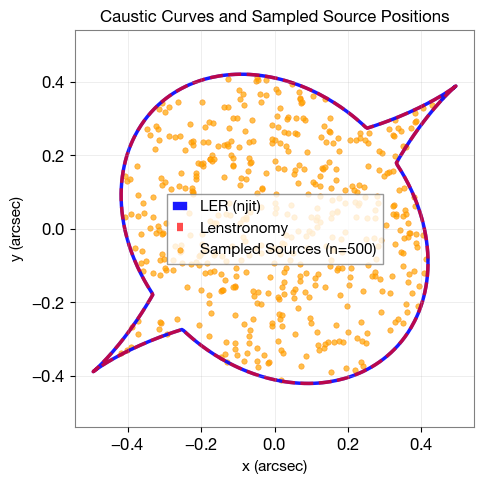

In [65]:
# Section 4b: Visualize Sampled Sources with Caustics
fig, ax = plt.subplots(figsize=(5, 5))

# Plot both caustic curves for comparison
ax.plot(pts_ler[0], pts_ler[1], 'b-', linewidth=2.5, label='LER (njit)', alpha=0.9)
ax.plot(pts_lenstronomy[0], pts_lenstronomy[1], 'r--', linewidth=2.5, label='Lenstronomy', alpha=0.7)

# Plot sampled sources
ax.scatter(xs, ys, s=15, color='orange', alpha=0.7, label=f'Sampled Sources (n={num_samples})', edgecolors='darkorange', linewidth=0.5)

ax.set_xlabel('x (arcsec)', fontsize=11)
ax.set_ylabel('y (arcsec)', fontsize=11)
ax.set_title('Caustic Curves and Sampled Source Positions', fontsize=12)
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

In [60]:
# Section 5: Validate Lens Equation Solving
print("\n" + "=" * 80)
print("SECTION 5: LENS EQUATION SOLVING VALIDATION")
print("=" * 80)

max_img = 4  # Maximum number of images for EPL+Shear is typically 4

# Arrays to store results
x_img_ler = np.full((num_samples, max_img), np.nan)
y_img_ler = np.full((num_samples, max_img), np.nan)
mu_ler = np.full((num_samples, max_img), np.nan)
tau_ler = np.full((num_samples, max_img), np.nan)
itype_ler = np.full((num_samples, max_img), np.nan)
n_img_ler = np.full(num_samples, 0, dtype=int)

# Solve lens equations using LER (njit)
print(f"\nSolving lens equations using LER (njit) for {num_samples} sources...")
start_time = time.time()
for i in range(num_samples):
    x, y, arrival_time, mu, image_type, n = image_position_analytical_njit(
        x_src=xs[i],
        y_src=ys[i],
        q=q,
        phi=phi,
        gamma=gamma,
        gamma1=gamma1,
        gamma2=gamma2,
        theta_E=theta_E,
    )

    n = min(n, max_img)
    x_img_ler[i, :n] = x[:n]
    y_img_ler[i, :n] = y[:n]
    mu_ler[i, :n] = mu[:n]
    
    # Convert fermat potential (dimensionless) to physical time delays
    tau_hat = arrival_time[:n]
    tau_phys = tau_hat * (theta_E * theta_E)  # Scale with theta_E^2
    tau_ = (D_dt / C_LIGHT) * tau_phys  # Convert to seconds
    tau_ler[i, :n] = tau_ - np.min(tau_)  # Convert to positive time delays relative to first arrival
    
    itype_ler[i, :n] = image_type[:n]
    n_img_ler[i] = n
        
ler_solve_time = time.time() - start_time
print(f"  LER solving time: {ler_solve_time:.6f} seconds")
print(f"  Average images per source: {np.mean(n_img_ler[n_img_ler > 0]):.2f}")


SECTION 5: LENS EQUATION SOLVING VALIDATION

Solving lens equations using LER (njit) for 500 sources...
  LER solving time: 0.114094 seconds
  Average images per source: 3.04


In [61]:
# Section 5b: Solve using Lenstronomy
print("\nSolving lens equations using Lenstronomy for comparison...")

# Setup Lenstronomy lens model
lens_model_list = ["EPL", "SHEAR"]
lensModel = LensModel(lens_model_list=lens_model_list, z_lens=zl, z_source=zs, cosmo=cosmo)
lens_eq_solver = LensEquationSolver(lensModel)

# Arrays to store Lenstronomy results
x_img_ls = np.full((num_samples, max_img), np.nan)
y_img_ls = np.full((num_samples, max_img), np.nan)
mu_ls = np.full((num_samples, max_img), np.nan)
tau_ls = np.full((num_samples, max_img), np.nan)
itype_ls = np.full((num_samples, max_img), np.nan)
n_img_ls = np.full(num_samples, 0, dtype=int)

start_time = time.time()
for i in range(num_samples):
    # Solve image positions
    theta_ra, theta_dec = lens_eq_solver.image_position_from_source(
        sourcePos_x=xs[i], sourcePos_y=ys[i],
        kwargs_lens=kwargs_lens,
        solver="analytical", magnification_limit=1.0/100.0,
        arrival_time_sort=True
    )
    n = min(len(theta_ra), max_img)
    x_img_ls[i, :n] = theta_ra[:n]
    y_img_ls[i, :n] = theta_dec[:n]

    # Compute magnifications
    magnifications = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)
    mu_ls[i, :n] = magnifications[:n]

    # Compute image types
    hessian = lensModel.hessian(theta_ra, theta_dec, kwargs_lens)
    determinant = (1 - hessian[0]) * (1 - hessian[3]) - hessian[1] * hessian[2]
    trace = 2 - hessian[0] - hessian[3]
    
    image_type_ls = []
    for j in range(len(theta_ra)):
        if determinant[j] < 0:
            image_type_ls.append(2.0)  
        elif trace[j] > 0:
            image_type_ls.append(1.0)  
        elif trace[j] < 0:
            image_type_ls.append(3.0)  
        else:
            image_type_ls.append(np.nan)
    itype_ls[i, :n] = image_type_ls[:n]

    # Compute time delays
    radian_to_arcseconds = 180.0 / np.pi * 3600.0
    days_to_seconds = 24.0 * 3600.0
    tau_tmp = (
        lensModel.arrival_time(theta_ra, theta_dec, kwargs_lens)
        * (radian_to_arcseconds) ** 2
        * days_to_seconds
    )[:n]
    tau_tmp = tau_tmp - np.min(tau_tmp)  # Convert to positive time delays relative to first arrival
    tau_ls[i, :n] = tau_tmp[:n]
    
    n_img_ls[i] = n

ls_solve_time = time.time() - start_time
print(f"  Lenstronomy solving time: {ls_solve_time:.6f} seconds")
print(f"  Average images per source: {np.mean(n_img_ls[n_img_ls > 0]):.2f}")


Solving lens equations using Lenstronomy for comparison...
  Lenstronomy solving time: 0.358626 seconds
  Average images per source: 3.04


In [62]:
# Section 6: Compare Results with Lenstronomy
print("\n" + "=" * 80)
print("SECTION 6: RESULT COMPARISON")
print("=" * 80)

# Compare number of images
n_img_match = np.sum(n_img_ler == n_img_ls)
n_img_total = np.sum((n_img_ler > 0) & (n_img_ls > 0))
print(f"\nImage count agreement: {n_img_match}/{n_img_total} ({100*n_img_match/max(n_img_total, 1):.1f}%)")

# Compare image positions (normalized by theta_E for dimensionless comparison)
valid_mask = (np.isfinite(x_img_ler)) & (np.isfinite(x_img_ls))
x_diff = x_img_ler[valid_mask] - x_img_ls[valid_mask]
y_diff = y_img_ler[valid_mask] - y_img_ls[valid_mask]

if len(x_diff) > 0:
    x_agree = np.sum(np.abs(x_diff) < 0.02) / len(x_diff)
    y_agree = np.sum(np.abs(y_diff) < 0.02) / len(y_diff)
    print(f"\nImage position agreement (tolerance=0.02):")
    print(f"  x-coordinate: {100*x_agree:.1f}%")
    print(f"  y-coordinate: {100*y_agree:.1f}%")
    print(f"  Max |Δx|: {np.max(np.abs(x_diff)):.2e}")
    print(f"  Max |Δy|: {np.max(np.abs(y_diff)):.2e}")
    print(f"  Mean |Δx|: {np.mean(np.abs(x_diff)):.2e}")
    print(f"  Mean |Δy|: {np.mean(np.abs(y_diff)):.2e}")

# Compare magnifications
valid_mag = (np.isfinite(mu_ler)) & (np.isfinite(mu_ls))
mu_diff_rel = np.abs((mu_ler[valid_mag] - mu_ls[valid_mag]) / mu_ls[valid_mag])

if len(mu_diff_rel) > 0:
    mu_agree = np.sum(mu_diff_rel < 0.05) / len(mu_diff_rel)
    print(f"\nMagnification agreement (relative tolerance=5%):")
    print(f"  Cases within tolerance: {100*mu_agree:.1f}%")
    print(f"  Max relative error: {100*np.max(mu_diff_rel):.2f}%")
    print(f"  Mean relative error: {100*np.mean(mu_diff_rel):.2f}%")

# Compare time delays
valid_tau = (np.isfinite(tau_ler)) & (np.isfinite(tau_ls)) & (tau_ls != 0)
tau_diff_rel = np.abs((tau_ler[valid_tau] - tau_ls[valid_tau]) / tau_ls[valid_tau])

if len(tau_diff_rel) > 0:
    tau_agree = np.sum(tau_diff_rel < 0.10) / len(tau_diff_rel)
    print(f"\nTime delay agreement (relative tolerance=10%):")
    print(f"  Cases within tolerance: {100*tau_agree:.1f}%")
    print(f"  Max relative error: {100*np.max(tau_diff_rel):.2f}%")
    print(f"  Mean relative error: {100*np.mean(tau_diff_rel):.2f}%")

# Compare image types
valid_mask = np.isfinite(itype_ler) & np.isfinite(itype_ls)
itype_match = np.sum(itype_ler[valid_mask] == itype_ls[valid_mask])
itype_total = np.sum(valid_mask)

if itype_total > 0:
    print(f"\nImage type classification agreement: {itype_match}/{itype_total} ({100*itype_match/itype_total:.1f}%)")


SECTION 6: RESULT COMPARISON

Image count agreement: 500/500 (100.0%)

Image position agreement (tolerance=0.02):
  x-coordinate: 100.0%
  y-coordinate: 100.0%
  Max |Δx|: 6.57e-11
  Max |Δy|: 5.60e-11
  Mean |Δx|: 1.36e-13
  Mean |Δy|: 1.41e-13

Magnification agreement (relative tolerance=5%):
  Cases within tolerance: 100.0%
  Max relative error: 0.00%
  Mean relative error: 0.00%

Time delay agreement (relative tolerance=10%):
  Cases within tolerance: 100.0%
  Max relative error: 0.00%
  Mean relative error: 0.00%

Image type classification agreement: 1520/1520 (100.0%)


In [63]:
# # Section 6b: Visualization of Comparison Results
# fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# # Plot 1: Image position differences
# valid_mask = (np.isfinite(x_img_ler)) & (np.isfinite(x_img_ls))
# ax = axes[0, 0]
# ax.scatter(x_img_ls[valid_mask], x_diff, s=30, alpha=0.6)
# ax.axhline(0, color='k', linestyle='--', alpha=0.3)
# ax.axhline(0.02, color='r', linestyle=':', alpha=0.5)
# ax.axhline(-0.02, color='r', linestyle=':', alpha=0.5)
# ax.set_xlabel('Lenstronomy x position')
# ax.set_ylabel('Difference (LER - Lenstronomy)')
# ax.set_title('Image x-Position Discrepancy')
# ax.grid(True, alpha=0.3)

# # Plot 2: Magnification comparison
# valid_mag = (np.isfinite(mu_ler)) & (np.isfinite(mu_ls))
# ax = axes[0, 1]
# ax.scatter(mu_ls[valid_mag], mu_ler[valid_mag], s=30, alpha=0.6)
# lims = [min(mu_ls[valid_mag].min(), mu_ler[valid_mag].min()),
#         max(mu_ls[valid_mag].max(), mu_ler[valid_mag].max())]
# ax.plot(lims, lims, 'k--', alpha=0.5)
# ax.set_xlabel('Lenstronomy Magnification')
# ax.set_ylabel('LER Magnification')
# ax.set_title('Magnification Comparison')
# ax.grid(True, alpha=0.3)

# # Plot 3: Time delay comparison
# valid_tau = (np.isfinite(tau_ler)) & (np.isfinite(tau_ls)) & (tau_ls != 0)
# ax = axes[1, 0]
# ax.scatter(tau_ls[valid_tau], tau_ler[valid_tau], s=30, alpha=0.6)
# lims_tau = [min(tau_ls[valid_tau].min(), tau_ler[valid_tau].min()),
#             max(tau_ls[valid_tau].max(), tau_ler[valid_tau].max())]
# ax.plot(lims_tau, lims_tau, 'k--', alpha=0.5)
# ax.set_xlabel('Lenstronomy Time Delay (days)')
# ax.set_ylabel('LER Time Delay (days)')
# ax.set_title('Time Delay Comparison')
# ax.grid(True, alpha=0.3)

# # Plot 4: Relative errors distribution
# ax = axes[1, 1]
# if len(tau_diff_rel) > 0:
#     ax.hist(100*tau_diff_rel, bins=30, alpha=0.7, edgecolor='black')
#     ax.axvline(10, color='r', linestyle='--', linewidth=2, label='10% tolerance')
#     ax.set_xlabel('Relative Error (%)')
#     ax.set_ylabel('Frequency')
#     ax.set_title('Time Delay Relative Error Distribution')
#     ax.legend()
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()


In [64]:
# # Section 7: Validation Summary
# print("\n" + "=" * 80)
# print("VALIDATION SUMMARY FOR EPL+SHEAR")
# print("=" * 80)

# summary_results = {
#     'Caustic X Match': agree_x,
#     'Caustic Y Match': agree_y,
#     'Image Count Agreement': n_img_match / max(n_img_total, 1) >= 0.95,
#     'Image Position Match': (x_agree >= 0.95) and (y_agree >= 0.95) if len(x_diff) > 0 else False,
#     'Magnification Match': mu_agree >= 0.95 if len(mu_diff_rel) > 0 else False,
#     'Time Delay Match': tau_agree >= 0.90 if len(tau_diff_rel) > 0 else False,
#     'Image Type Match': (itype_match / itype_total >= 0.95) if itype_total > 0 else False,
# }

# print("\nTest Results:")
# for test_name, passed in summary_results.items():
#     status = "✓ PASS" if passed else "✗ FAIL"
#     print(f"  {test_name:<30} {status}")

# overall_pass = all(summary_results.values())
# print(f"\n{'Overall Validation':<30} {'✓ PASS' if overall_pass else '✗ FAIL'}")

# print("\nPerformance Metrics:")
# print(f"  Caustic computation time:")
# print(f"    LER:         {ler_time:.6f} seconds")
# print(f"    Lenstronomy: {ls_time:.6f} seconds")
# print(f"    Speedup:     {ls_time/ler_time:.2f}x")
# print(f"  Lens equation solving (per source):")
# print(f"    LER:         {ler_solve_time/num_samples:.6f} seconds")
# print(f"    Lenstronomy: {ls_solve_time/num_samples:.6f} seconds")
# print(f"    Speedup:     {ls_solve_time/ler_solve_time:.2f}x")

# print("\n" + "=" * 80)